# 02 — What happened to this business

Notebook 01 gave us a clean dataset. Now we use it to answer a simple question:

**Over these six years, did Softwood do better or worse — and why?**

This notebook has no models in it. It is the part of the project where we find
out what the actual problem is, before deciding what to build.

One rule for this whole notebook: 2025 is excluded from every year-on-year
comparison. The data stops in April 2025, so a full year and a four-month stub
cannot be compared honestly.


In [1]:
import sys
sys.path.append("../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import viz

viz.use_style()
pd.set_option("display.width", 200)

deals = pd.read_csv("../data/processed/deals_clean.csv",
                    parse_dates=["contract_date", "dispatch_date"])
full_years = deals[deals.contract_year <= 2024]

print(f"{len(deals):,} deals total, {len(full_years):,} in complete years (2019-2024)")

4,590 deals total, 4,550 in complete years (2019-2024)


## The headline

Softwood's income is the commission it earns. Here it is, year by year.

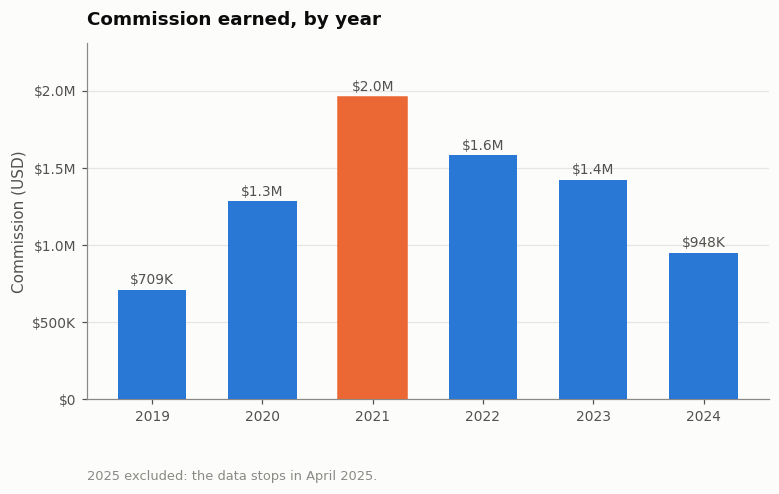

,deals,volume,commission,brands,avg_deal_size,effective_rate
contract_year,,,,,,
2019,455,17933241.86,708920.730,23,39413.7184,0.0395
2020,772,32384046.20,1281204.250,15,41948.2464,0.0396
2021,911,47910548.64,1957060.430,12,52591.1621,0.0408
2022,666,36371269.70,1579928.529,9,54611.5161,0.0434
2023,891,35888365.10,1421148.290,13,40278.7487,0.0396
2024,855,22969285.59,948037.640,26,26864.6615,0.0413


In [2]:
yearly = full_years.groupby("contract_year").agg(
    deals=("commission_usd", "size"),
    volume=("deal_value_usd", "sum"),
    commission=("commission_usd", "sum"),
    brands=("customer_brand", "nunique"))
yearly["avg_deal_size"] = yearly.volume / yearly.deals
yearly["effective_rate"] = yearly.commission / yearly.volume

fig, ax = plt.subplots(figsize=(8, 4.2))
bars = ax.bar(yearly.index, yearly.commission, color=viz.SERIES[0], width=0.62, zorder=3)
peak = yearly.commission.idxmax()
bars[list(yearly.index).index(peak)].set_color(viz.SERIES[1])
for year, value in yearly.commission.items():
    ax.text(year, value + 40_000, viz.money(value), ha="center",
            fontsize=9, color=viz.INK_SOFT)
ax.set_title("Commission earned, by year")
ax.set_ylabel("Commission (USD)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(viz.money))
ax.set_ylim(0, yearly.commission.max() * 1.18)
viz.grid(ax)
viz.caption(ax, "2025 excluded: the data stops in April 2025.")
plt.show()

yearly.round(4)

The business peaked in 2021 at just under \$2.0M and has fallen every year
since. 2024 came in at \$0.95M.

**That is a 51.6% fall in three years.** This is the problem. Everything that
follows is an attempt to explain it.

## Why did it fall? Only three things can move commission

Commission income is the product of exactly three numbers:

$$\text{commission} = \text{number of deals} \times \text{average deal size} \times \text{commission rate}$$

If income halved, at least one of those three had to move. There is no fourth
explanation. Let us check each one.


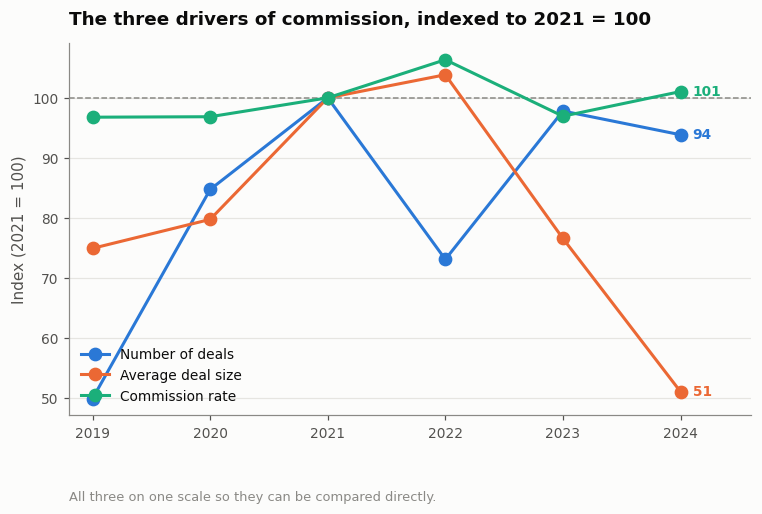

,2021,2024,change
Number of deals,9.110000e+02,855.0000,-6.1%
Average deal size ($),5.259116e+04,26864.6615,-48.9%
Commission rate,4.080000e-02,0.0413,+1.0%
Commission ($),1.957060e+06,948037.6400,-51.6%


In [3]:
indexed = pd.DataFrame({
    "Number of deals": yearly.deals,
    "Average deal size": yearly.avg_deal_size,
    "Commission rate": yearly.effective_rate,
})
indexed = indexed / indexed.loc[2021] * 100      # 2021 = 100, the peak year

fig, ax = plt.subplots(figsize=(8, 4.4))
for i, col in enumerate(indexed.columns):
    ax.plot(indexed.index, indexed[col], color=viz.SERIES[i], marker="o", label=col, zorder=3)
    ax.annotate(f"{indexed[col].iloc[-1]:.0f}",
                (indexed.index[-1], indexed[col].iloc[-1]),
                xytext=(8, 0), textcoords="offset points",
                color=viz.SERIES[i], fontsize=9, va="center", fontweight="bold")
ax.axhline(100, color=viz.INK_MUTED, lw=1, ls="--", zorder=2)
ax.set_title("The three drivers of commission, indexed to 2021 = 100")
ax.set_ylabel("Index (2021 = 100)")
ax.set_xlim(2018.8, 2024.6)
ax.legend(loc="lower left")
viz.grid(ax)
viz.caption(ax, "All three on one scale so they can be compared directly.")
plt.show()

change = pd.DataFrame({
    "2021": [yearly.deals[2021], yearly.avg_deal_size[2021], yearly.effective_rate[2021], yearly.commission[2021]],
    "2024": [yearly.deals[2024], yearly.avg_deal_size[2024], yearly.effective_rate[2024], yearly.commission[2024]],
}, index=["Number of deals", "Average deal size ($)", "Commission rate", "Commission ($)"])
change["change"] = (change["2024"] / change["2021"] - 1).map("{:+.1%}".format)
change.round(4)

**This is the answer, and it is very clean.**

- Number of deals: **-6.1%**. Essentially flat. They are still winning work.
- Commission rate: **+1.0%**. Flat. They are not being squeezed on price.
- Average deal size: **-48.9%**. This is the entire story.

Softwood is doing roughly the same number of deals, at the same rate, but each
deal is worth half what it used to be.

That immediately kills one theory worth naming, because it is the theory most
people would reach for first: **this is not a pricing problem.** Nobody
negotiated the company's rates down. Whatever is wrong, it is upstream of price.

### So why are deals smaller?

A deal's value is quantity multiplied by unit price. Only one of those can be
responsible.


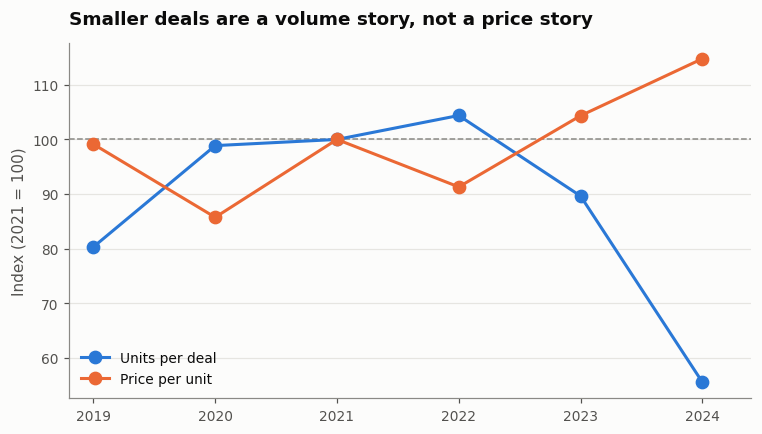

,total_units,units_per_deal,unit_price
contract_year,,,
2019,3896708.0,8564.19,5.70
2020,8139091.0,10542.86,4.93
2021,9714072.0,10663.09,5.75
2022,7413140.0,11130.84,5.25
2023,8516396.0,9558.24,6.00
2024,5064586.0,5923.49,6.60


In [4]:
size = full_years.groupby("contract_year").agg(
    units_per_deal=("contract_qty", "mean"),
    unit_price=("unit_rate_usd", "median"),
    total_units=("contract_qty", "sum"))
size["units_per_deal_idx"] = size.units_per_deal / size.units_per_deal[2021] * 100
size["unit_price_idx"] = size.unit_price / size.unit_price[2021] * 100

fig, ax = plt.subplots(figsize=(8, 4.2))
ax.plot(size.index, size.units_per_deal_idx, color=viz.SERIES[0], marker="o",
        label="Units per deal", zorder=3)
ax.plot(size.index, size.unit_price_idx, color=viz.SERIES[1], marker="o",
        label="Price per unit", zorder=3)
ax.axhline(100, color=viz.INK_MUTED, lw=1, ls="--", zorder=2)
ax.set_title("Smaller deals are a volume story, not a price story")
ax.set_ylabel("Index (2021 = 100)")
ax.set_xlim(2018.8, 2024.4)
ax.legend(loc="lower left")
viz.grid(ax)
plt.show()

size[["total_units", "units_per_deal", "unit_price"]].round(2)

Unit prices actually went **up** — the median unit price rose from \$5.75 to
\$6.60. What collapsed is quantity: total units fell from 9.7 million to 5.1
million, and units per deal fell 44%.

So the chain is:

> fewer units ordered -> smaller deals -> less commission

Not price. Not rate. **Volume.**

## Who stopped ordering?

Softwood's customer list is short and top-heavy. Let us see how top-heavy, and
whether the volume drop is spread across customers or concentrated in one.


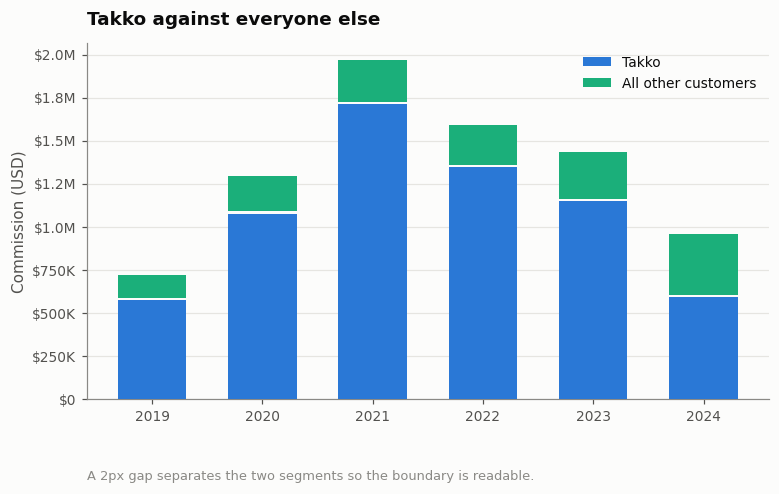

,largest customer,their share of commission,number of brands active
contract_year,,,
2019,Takko,81.1%,23
2020,Takko,84.1%,15
2021,Takko,87.5%,12
2022,Takko,85.3%,9
2023,Takko,81.0%,13
2024,Takko,62.5%,26


In [5]:
by_brand = full_years.pivot_table(index="customer_brand", columns="contract_year",
                                  values="commission_usd", aggfunc="sum").fillna(0)
share_top1 = by_brand.max() / by_brand.sum()
top_brand = by_brand.idxmax()

fig, ax = plt.subplots(figsize=(8, 4.2))
biggest = by_brand.sum(axis=1).idxmax()
rest = by_brand.drop(index=biggest).sum()
ax.bar(by_brand.columns, by_brand.loc[biggest], color=viz.SERIES[0],
       width=0.62, label=biggest, zorder=3)
ax.bar(by_brand.columns, rest, bottom=by_brand.loc[biggest] + 12_000,
       color=viz.SERIES[2], width=0.62, label="All other customers", zorder=3)
ax.set_title(f"{biggest} against everyone else")
ax.set_ylabel("Commission (USD)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(viz.money))
ax.legend(loc="upper right")
viz.grid(ax)
viz.caption(ax, "A 2px gap separates the two segments so the boundary is readable.")
plt.show()

pd.DataFrame({
    "largest customer": top_brand,
    "their share of commission": share_top1.map("{:.1%}".format),
    "number of brands active": by_brand.gt(0).sum(),
})

Takko has been between **62% and 88%** of Softwood's entire income every single
year. That is not a customer, that is the business.

Now the decisive number.


In [6]:
movement = (by_brand[2024] - by_brand[2021]).sort_values()
company_change = yearly.commission[2024] - yearly.commission[2021]

print(f"Whole company, 2021 -> 2024:      {viz.money(company_change)}")
print(f"Takko alone, 2021 -> 2024:        {viz.money(movement['Takko'])}")
print(f"Everyone else combined:           {viz.money(movement.drop('Takko').sum())}")
print()
print("Biggest movers:")
pd.DataFrame({"change 2021 -> 2024": movement}).query(
    "abs(`change 2021 -> 2024`) > 3000").round(0)

Whole company, 2021 -> 2024:      $-1.0M
Takko alone, 2021 -> 2024:        $-1.1M
Everyone else combined:           $111K

Biggest movers:


,change 2021 -> 2024
customer_brand,
Takko,-1119796.0
Reporter Young,-37306.0
Piazza Italia,-26649.0
Tiffosi,-17104.0
Wunsche Group,-9558.0
Get Over,-4178.0
Carisma,3748.0
Dimotex,4397.0
Altex,7094.0


**Takko's decline is larger than the company's decline.**

The company lost \$1.01M. Takko alone accounts for \$1.12M of loss. Every other
customer combined actually *added* about \$0.11M, partly cushioning the fall.

So the six-year story compresses to one sentence:

> Softwood did not lose its business. It lost most of one customer, and that one
> customer was most of its business.

And the company did respond. The number of active brands went from 12 in 2021 to
26 in 2024 — they went out and found new buyers. The problem is scale: the new
buyers are small, so 14 extra brands replaced only about a tenth of what Takko
took away.

## An honest correction to our own plan

Before this notebook, the plan for this project was to build a commission rate
benchmark — a tool that spots deals priced below where they should be.

The decomposition above says rates did **not** cause the decline. So we have to
be straight about what a rate benchmark can and cannot claim: it will not fix the
revenue decline, and we should never present it as if it does.

But that is a statement about the *average* rate across the whole book. It says
nothing about whether individual deals are priced consistently. Those are
different questions, and the second one is still worth asking — as long as we
first check that there is real variation to find. If two deals in the same
situation always get the same rate, there is no benchmark to build and we should
abandon the idea rather than dress it up.

So: is there variation?


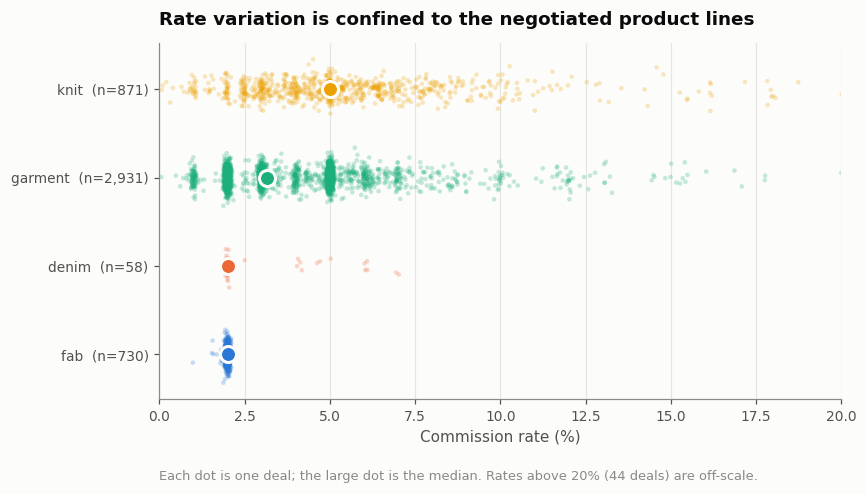

,deals,p25,median,p75,IQR
product_division,,,,,
denim,58,0.0200,0.0200,0.0200,0.0000
fab,730,0.0200,0.0200,0.0200,0.0000
garment,2931,0.0200,0.0314,0.0500,0.0300
knit,871,0.0365,0.0500,0.0646,0.0281


In [7]:
spread = deals.groupby("product_division").commission_pct.agg(
    deals="size", p25=lambda s: s.quantile(.25), median="median",
    p75=lambda s: s.quantile(.75))
spread["IQR"] = spread.p75 - spread.p25

order = ["fab", "denim", "garment", "knit"]
fig, ax = plt.subplots(figsize=(8, 4.2))
for i, div in enumerate(order):
    values = deals.loc[deals.product_division == div, "commission_pct"] * 100
    ax.scatter(values + np.random.default_rng(0).normal(0, 0.05, len(values)),
               np.full(len(values), i) + np.random.default_rng(1).normal(0, 0.09, len(values)),
               s=9, alpha=0.25, color=viz.SERIES[i], edgecolors="none", zorder=3)
    ax.scatter([values.median()], [i], s=110, color=viz.SERIES[i],
               edgecolors=viz.SURFACE, linewidths=2, zorder=5)
ax.set_yticks(range(len(order)), [f"{d}  (n={spread.deals[d]:,})" for d in order])
ax.set_xlabel("Commission rate (%)")
ax.set_xlim(0, 20)
ax.set_title("Rate variation is confined to the negotiated product lines")
viz.grid(ax, axis="x")
viz.caption(ax, "Each dot is one deal; the large dot is the median. Rates above 20% (44 deals) are off-scale.")
plt.show()

spread.round(4)

This splits the business cleanly in two, and it matters for everything we build
next.

**Fabric and denim deals have an inter-quartile range of exactly zero.** Every
deal is at the contract rate. There is no variation, so there is nothing to
benchmark and nothing to recover. Building a pricing tool for these would be
inventing a problem.

**Garment and knit deals vary enormously.** The knit line has an IQR of 2.8
percentage points on a 5.0% median, and its 90th percentile rate is 3.7 times its
10th percentile. These are negotiated one at a time, and they are 83% of all
deals.

Let us make sure this is real variation and not just different customers being
mixed together — by looking inside a single customer, a single supplier, and a
single year, where nothing else is changing.


In [8]:
pair = deals[(deals.customer == "Takko") & (deals.supplier == "Samad Rubber")]
inside = pair.groupby("contract_year").commission_pct.agg(
    deals="size", lowest="min", p10=lambda s: s.quantile(.10),
    median="median", p90=lambda s: s.quantile(.90), highest="max")
print(f"Takko buying from Samad Rubber: {len(pair)} deals over {pair.contract_year.nunique()} years\n")
(inside * [1, 100, 100, 100, 100, 100]).round(2)

Takko buying from Samad Rubber: 315 deals over 6 years



,deals,lowest,p10,median,p90,highest
contract_year,,,,,,
2019,33,3.00,3.00,5.00,5.00,5.00
2020,85,2.85,3.00,5.00,5.00,5.92
2021,81,0.86,2.60,4.83,6.20,8.27
2022,48,0.80,4.14,5.59,11.67,11.67
2023,31,2.00,4.49,5.00,6.60,7.09
2024,37,1.32,3.23,4.75,5.57,6.79


Same buyer, same mill, same year — and in 2021 the rate ranges from **0.86% to
8.27%**. In 2022, from 0.80% to 11.67%.

That is not explained by who the customer is or who the supplier is, because
those are held fixed here. Something else is driving it, or nothing is — and
"nothing" would mean the rate depends on who happened to negotiate that day.

Either way, there is real variation to work with. The benchmark idea survives.

## Where this leaves the project

What we now know, with evidence:

1. **The decline is a volume problem concentrated in one customer.** Takko
   halved its order quantity. Deal count and commission rates held steady.
2. **Customer concentration is the standing risk.** One buyer has been 62-88% of
   income every year. Diversification has started but the new customers are small.
3. **The company runs two pricing models.** Fabric is fixed at 2% and needs no
   attention. Garment and knit are negotiated, vary by a factor of three or more,
   and are 83% of deals.
4. **A rate benchmark is worth building — for the negotiated lines only**, and it
   addresses pricing consistency, not the revenue decline.

Notebook 03 builds that benchmark. (An earlier plan was to first group the 2,401
free-text style names into product families and benchmark within a family;
notebook 05 shows why that was tested and dropped.)
